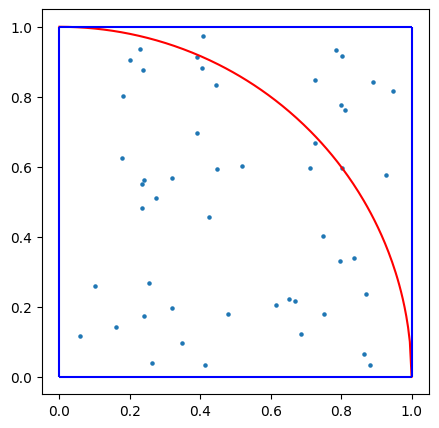

In [37]:
import matplotlib.pyplot as plt
import numpy as np

anzahlPunkte = 50
x = np.random.uniform(0,1,anzahlPunkte)
y = np.random.uniform(0,1,anzahlPunkte)

x_k = np.linspace(0,1,200)
y_k = np.sqrt(1 - x_k**2)

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax = plt.scatter(x,y,s=5)
ax = plt.plot(x_k,y_k,color="red")
ax = plt.vlines([0,1],0,1,color="blue")
ax = plt.hlines([0,1],0,1,color="blue")
plt.show()


In [52]:
def Estimator(n):
    x = np.random.uniform(0,1,n)
    y = np.random.uniform(0,1,n)
    kreis = [1 for i in range(n) if x[i]**2 + y[i]**2 <= 1]        
    return 4 * sum(kreis)/n
print(Estimator(10000000)-np.pi)

4.2146410206722607e-05


In [56]:
def randSelect(A,i):
    n = len(A)
    if n==1:
        return A[n-1]
    pivot = np.random.randint(n)
    L = []
    R = []
    for j in range(len(A)):
        if j != pivot:
            if A[j] < A[pivot]:
                L.append(A[j])
            else:
                R.append(A[j])
    print(L,A[pivot],R,"Das pivot ist aktuell",pivot)
    if i < len(L): # die i-kleinste Zahl muss in L sein
        return randSelect(L,i)
    elif i == len(L): # in L sind die i-kleinsten Zahlen
        return A[pivot] # das aktuelle pivot ist ein Treffer
    else:
        return randSelect(R,i-(len(L)+1)) # dann suche ich die i-(len(L)+1)-kleinste Zahl in R

randSelect([8,4,7,3,2,5,5,8,5,2],3)

[4, 3, 2, 2] 5 [8, 7, 5, 8, 5] Das pivot ist aktuell 6
[2, 2] 3 [4] Das pivot ist aktuell 1


4

In [362]:
def linearSearch(Liste,Element):
    for i in range(len(Liste)):
        if Liste[i] == Element: return True
    return False
linearSearch([1,2,3,4],1)

True

In [361]:
def insertionSort(Liste):
    for i in range(1,len(Liste)):
        j = i
        while j > 0 and Liste[j] < Liste[j-1]:
            temp = Liste[j]
            Liste[j] = Liste[j-1]
            Liste[j-1] = temp
            j = j-1

lst = [8,7,6,5,4,3,2,1]
insertionSort(lst)
lst

[1, 2, 3, 4, 5, 6, 7, 8]

In [57]:
import random as rd

def randomized_quicksort(arr):
    if len(arr) <= 1:
        return arr
    pivot = rd.choice(arr)  # Zufällige Pivot-Wahl
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return randomized_quicksort(left) + middle + randomized_quicksort(right)
    
randomized_quicksort([7,7,9,7,7,9,4,3,5,7,1,2,7,1,9,-1,6])

[-1, 1, 1, 2, 3, 4, 5, 6, 7, 7, 7, 7, 7, 7, 9, 9, 9]

In [364]:
import random
import copy

def find_min_cut(graph):
    # Kopiere den Graphen, damit das Original unverändert bleibt
    g = copy.deepcopy(graph)

    while len(g) > 2:
        # Wähle zufällig eine Kante (u, v)
        u = random.choice(list(g.keys()))
        v = random.choice(g[u])

        # Verschmelze v in u
        g[u].extend(g[v])

        # Ersetze alle Vorkommen von v durch u
        for node in g[v]:
            g[node] = [u if x == v else x for x in g[node]]

        # Entferne die Knoten, die sich selbst verbinden (Schleifen)
        g[u] = [x for x in g[u] if x != u]

        # Entferne v aus dem Graphen
        del g[v]

    # Die Anzahl der verbleibenden Kanten ist der Min-Cut-Schätzwert
    return len(list(g.values())[0])

# Beispielgraph als Adjazenzliste
graph = {
    'A': ['B', 'C', 'D'],
    'B': ['A', 'C', 'D'],
    'C': ['A', 'B', 'D'],
    'D': ['A', 'B', 'C']
}

# Mehrere Durchläufe für höhere Genauigkeit
min_cut = min(find_min_cut(graph) for _ in range(10))
print("Geschätzter Minimum Cut:", min_cut)

Geschätzter Minimum Cut: 3
